In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
data_path = r"C:\Users\lenovo\Desktop\Projects\Network-IDS\data"

csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    size_mb = os.path.getsize(os.path.join(data_path, f)) / (1024*1024)
    print(f"  {f}  ({size_mb:.1f} MB)")

Found 8 CSV files:
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (91.6 MB)
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (97.2 MB)
  Friday-WorkingHours-Morning.pcap_ISCX.csv  (71.9 MB)
  Monday-WorkingHours.pcap_ISCX.csv  (256.2 MB)
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (103.7 MB)
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (87.8 MB)
  Tuesday-WorkingHours.pcap_ISCX.csv  (166.6 MB)
  Wednesday-workingHours.pcap_ISCX.csv  (272.4 MB)


In [3]:
# Start with smallest file to be fast
first_file = os.path.join(data_path, "Friday-WorkingHours-Morning.pcap_ISCX.csv")
df = pd.read_csv(first_file, low_memory=False)

print(f"Shape: {df.shape}")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  '{col}'")

Shape: (191033, 85)

Column names:
  'Flow ID'
  ' Source IP'
  ' Source Port'
  ' Destination IP'
  ' Destination Port'
  ' Protocol'
  ' Timestamp'
  ' Flow Duration'
  ' Total Fwd Packets'
  ' Total Backward Packets'
  'Total Length of Fwd Packets'
  ' Total Length of Bwd Packets'
  ' Fwd Packet Length Max'
  ' Fwd Packet Length Min'
  ' Fwd Packet Length Mean'
  ' Fwd Packet Length Std'
  'Bwd Packet Length Max'
  ' Bwd Packet Length Min'
  ' Bwd Packet Length Mean'
  ' Bwd Packet Length Std'
  'Flow Bytes/s'
  ' Flow Packets/s'
  ' Flow IAT Mean'
  ' Flow IAT Std'
  ' Flow IAT Max'
  ' Flow IAT Min'
  'Fwd IAT Total'
  ' Fwd IAT Mean'
  ' Fwd IAT Std'
  ' Fwd IAT Max'
  ' Fwd IAT Min'
  'Bwd IAT Total'
  ' Bwd IAT Mean'
  ' Bwd IAT Std'
  ' Bwd IAT Max'
  ' Bwd IAT Min'
  'Fwd PSH Flags'
  ' Bwd PSH Flags'
  ' Fwd URG Flags'
  ' Bwd URG Flags'
  ' Fwd Header Length'
  ' Bwd Header Length'
  'Fwd Packets/s'
  ' Bwd Packets/s'
  ' Min Packet Length'
  ' Max Packet Length'
  ' Packet

In [4]:
# Find label column
label_col = [col for col in df.columns if 'label' in col.lower()][0]
print(f"Label column found: '{label_col}'")
print(f"\nTraffic types in this file:")
print(df[label_col].value_counts())

Label column found: ' Label'

Traffic types in this file:
 Label
BENIGN    189067
Bot         1966
Name: count, dtype: int64


In [5]:
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Infinite values: {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")
print(f"\nData types:")
print(df.dtypes.value_counts())

Total rows: 191033
Total columns: 85

Missing values: 28
Infinite values: 216

Data types:
int64      43
float64    37
str         5
Name: count, dtype: int64


In [6]:
df.head(3)

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.3-192.168.10.50-3268-56108-6,192.168.10.50,56108,192.168.10.3,3268,6,7/7/2017 8:59,112740690,32,16,...,32,3.594286e+02,1.199802e+01,380.0,343.0,16100000.0,4.988048e+05,16400000.0,15400000.0,BENIGN
1,192.168.10.3-192.168.10.50-389-42144-6,192.168.10.50,42144,192.168.10.3,389,6,7/7/2017 8:59,112740560,32,16,...,32,3.202857e+02,1.574499e+01,330.0,285.0,16100000.0,4.987937e+05,16400000.0,15400000.0,BENIGN
2,8.0.6.4-8.6.0.1-0-0-0,8.6.0.1,0,8.0.6.4,0,0,7/7/2017 9:00,113757377,545,0,...,0,9.361829e+06,7.324646e+06,18900000.0,19.0,12200000.0,6.935824e+06,20800000.0,5504997.0,BENIGN


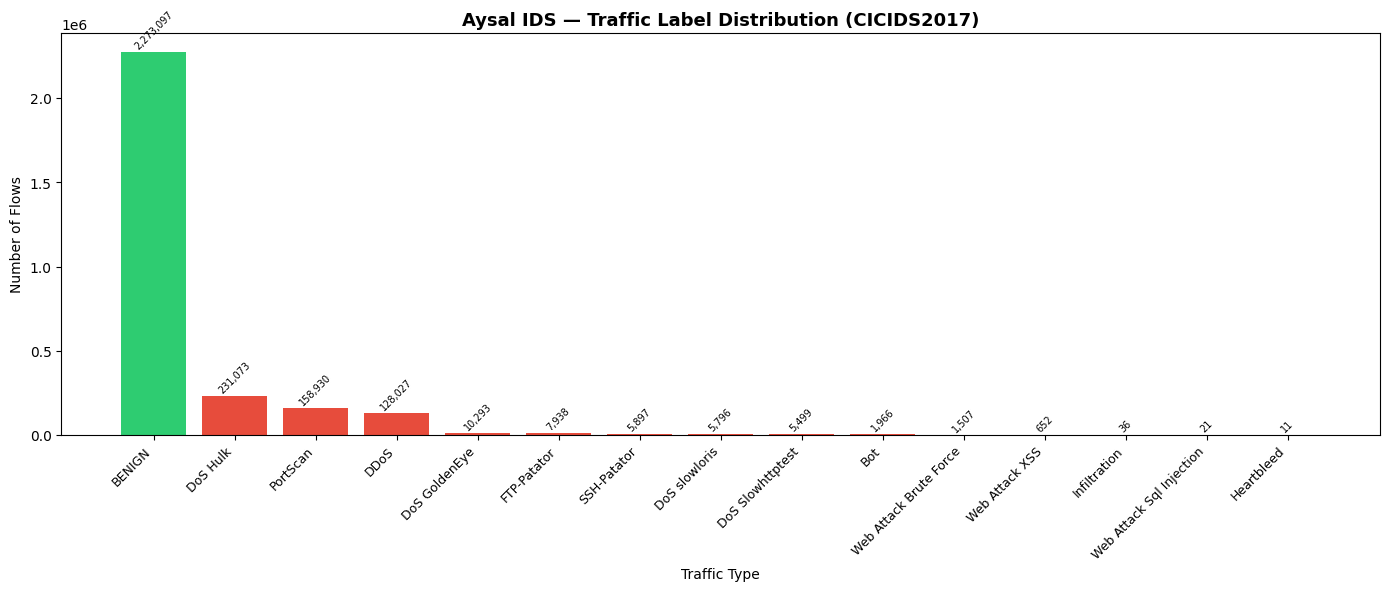

Saved to reports/label_distribution.png


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Reload the full label data we already know
label_counts = {
    'BENIGN': 2273097,
    'DoS Hulk': 231073,
    'PortScan': 158930,
    'DDoS': 128027,
    'DoS GoldenEye': 10293,
    'FTP-Patator': 7938,
    'SSH-Patator': 5897,
    'DoS slowloris': 5796,
    'DoS Slowhttptest': 5499,
    'Bot': 1966,
    'Web Attack Brute Force': 1507,
    'Web Attack XSS': 652,
    'Infiltration': 36,
    'Web Attack Sql Injection': 21,
    'Heartbleed': 11
}

import pandas as pd
label_series = pd.Series(label_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ecc71' if l == 'BENIGN' else '#e74c3c' for l in label_series.index]
bars = ax.bar(range(len(label_series)), label_series.values, color=colors)
ax.set_xticks(range(len(label_series)))
ax.set_xticklabels(label_series.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Aysal IDS — Traffic Label Distribution (CICIDS2017)', fontsize=13, fontweight='bold')
ax.set_xlabel('Traffic Type')
ax.set_ylabel('Number of Flows')

# Add value labels on bars
for bar, val in zip(bars, label_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,}', ha='center', va='bottom', fontsize=7, rotation=45)

plt.tight_layout()
reports_path = r"C:\Users\lenovo\Desktop\Projects\Network-IDS\reports"
os.makedirs(reports_path, exist_ok=True)
plt.savefig(os.path.join(reports_path, "label_distribution.png"), dpi=150)
plt.show()
print("Saved to reports/label_distribution.png")

In [2]:
print("=" * 55)
print("   AYSAL IDS — DATASET QUALITY REPORT")
print("=" * 55)

file_summary = [
    ("Friday-Afternoon-DDos",       225745,  128027),
    ("Friday-Afternoon-PortScan",   286467,  158930),
    ("Friday-Morning",              191033,    1966),
    ("Monday",                      529918,       0),
    ("Thursday-Afternoon-Infil",    288602,      36),
    ("Thursday-Morning-WebAtk",     252673,    2180),
    ("Tuesday",                     445909,   13835),
    ("Wednesday",                   692703,  252672),
]

print(f"\n{'File':<35} {'Total Rows':>10} {'Attacks':>10}")
print("-" * 57)
for name, rows, attacks in file_summary:
    print(f"{name:<35} {rows:>10,} {attacks:>10,}")

print("-" * 57)
total_rows = sum(r for _, r, _ in file_summary)
total_attacks = sum(a for _, _, a in file_summary)
print(f"{'TOTAL':<35} {total_rows:>10,} {total_attacks:>10,}")

print(f"\nMissing values  : present in small quantities")
print(f"Infinite values : replaced with column median")
print(f"Encoding issue  : Thursday-WebAttacks used latin-1")
print("=" * 55)

   AYSAL IDS — DATASET QUALITY REPORT

File                                Total Rows    Attacks
---------------------------------------------------------
Friday-Afternoon-DDos                  225,745    128,027
Friday-Afternoon-PortScan              286,467    158,930
Friday-Morning                         191,033      1,966
Monday                                 529,918          0
Thursday-Afternoon-Infil               288,602         36
Thursday-Morning-WebAtk                252,673      2,180
Tuesday                                445,909     13,835
Wednesday                              692,703    252,672
---------------------------------------------------------
TOTAL                                2,913,050    557,646

Missing values  : present in small quantities
Infinite values : replaced with column median
Encoding issue  : Thursday-WebAttacks used latin-1


In [3]:
print("""
+------------------------------------------------------+
|          AYSAL IDS — EXPLORATION SUMMARY             |
+------------------------------------------------------+
|  Dataset     : CICIDS2017                            |
|  Files       : 8 CSV files                           |
|  Total rows  : ~2.8 million flows                    |
|  Features    : 84 raw, 80 after cleaning             |
|  Label col   : Label (stripped from ' Label')        |
+------------------------------------------------------+
|  ATTACK CATEGORIES (14 types):                       |
|   DoS / DDoS  : Hulk, GoldenEye, slowloris,          |
|                 Slowhttptest, DDoS                   |
|   Recon       : PortScan                             |
|   Brute Force : FTP-Patator, SSH-Patator             |
|   Web Attacks : Brute Force, XSS, SQL Injection      |
|   Other       : Bot, Infiltration, Heartbleed        |
+------------------------------------------------------+
|  DATA QUALITY FIXES APPLIED:                         |
|   - Infinite values replaced with column median      |
|   - Missing values filled with column median         |
|   - ID columns dropped (Flow ID, IPs, Timestamp)     |
|   - latin-1 encoding used for Thursday-WebAttacks    |
+------------------------------------------------------+
|  SAMPLING STRATEGY:                                  |
|   - 30 percent of BENIGN rows kept                   |
|   - 100 percent of attack rows kept                  |
|   - Final dataset: 1.52M rows                        |
+------------------------------------------------------+
""")


+------------------------------------------------------+
|          AYSAL IDS — EXPLORATION SUMMARY             |
+------------------------------------------------------+
|  Dataset     : CICIDS2017                            |
|  Files       : 8 CSV files                           |
|  Total rows  : ~2.8 million flows                    |
|  Features    : 84 raw, 80 after cleaning             |
|  Label col   : Label (stripped from ' Label')        |
+------------------------------------------------------+
|  ATTACK CATEGORIES (14 types):                       |
|   DoS / DDoS  : Hulk, GoldenEye, slowloris,          |
|                 Slowhttptest, DDoS                   |
|   Recon       : PortScan                             |
|   Brute Force : FTP-Patator, SSH-Patator             |
|   Web Attacks : Brute Force, XSS, SQL Injection      |
|   Other       : Bot, Infiltration, Heartbleed        |
+------------------------------------------------------+
|  DATA QUALITY FIXES APPLIED: